In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("titanic.csv")
# df.head(100)
print(df)
df.info()

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

In [2]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


df.shape

check missing valuess

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum().sum()

np.int64(866)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Age"].fillna(df.groupby(["Pclass","Sex"])["Age"].transform("median"),inplace=True)
df["Age"].isnull().sum()
df
# df.groupby(["Pclass","Sex"])["Age"].transform("median")
# print(df)

C:\Users\Ayan Ahmad\AppData\Local\Temp\ipykernel_20280\155714368.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df.groupby(["Pclass","Sex"])["Age"].transform("median"),inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
common_port = df["Embarked"].mode()[0]
df["Embarked"].fillna(common_port,inplace=True)
df.isnull().sum()
df.head(20)

C:\Users\Ayan Ahmad\AppData\Local\Temp\ipykernel_20280\741826075.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(common_port,inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,25.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Codeshare logo
 ShareSign UpLog In
1
## **Phase 2: Data Cleaning and Preprocessing**
2
​
3
Our initial inspection revealed missing values in `Age`, `Cabin`, and `Embarked`. We must address these before we can proceed with analysis. We will also clean the `Name` column to extract useful information.
4
​
5
### **Problems to Solve:**
6
1.  **`Age` Column:** Has 177 missing values. We will fill these with the median age, grouped by `Pclass` and `Sex`, to be more accurate.
7
2.  **`Cabin` Column:** Has 687 missing values (too many to be useful). We will drop this column.
8
3.  **`Embarked` Column:** Has only 2 missing values. We will fill these with the most common port (the mode).
9
4.  **`Name` Column:** This column is messy. We will extract the `Title` (e.g., Mr., Mrs.) and create `LastName` and `FirstName` columns for better analysis.





px
Hide Ads


In [8]:
# --- Problem 1: Fill missing 'Age' values ---
# Calculate the median age for each Pclass/Sex group and fill the missing values
df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'), inplace=True)


# --- Problem 2: Drop the 'Cabin' column ---
df.drop('Cabin', axis=1, inplace=True)

# --- Problem 3: Fill missing 'Embarked' values ---
# Find the most common port (mode) and fill the missing values
common_port = df['Embarked'].mode()[0]
df['Embarked'].fillna(common_port, inplace=True)

# --- Problem 4: Clean the 'Name' column and extract features ---
# 4a. Extract and Clean the Title
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# 4b. Split the Name into LastName and FirstName
df[['LastName', 'FirstName']] = df['Name'].str.split(',', n=1, expand=True)

# 4c. Clean the FirstName part (remove title and parentheses)
df['FirstName'] = df['FirstName'].str.replace(r'^[A-Za-z]+\.\s*', '', regex=True)
df['FirstName'] = df['FirstName'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

# --- Create 'FamilySize' feature ---
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# # --- Verify that all missing values are handled and new features are created ---
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset with new features:")
df[['Name', 'Title', 'LastName', 'FirstName', 'FamilySize']].head()


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
LastName       0
FirstName      0
FamilySize     0
dtype: int64

Dataset with new features:


<>:16: SyntaxWarning: invalid escape sequence '\.'
<>:16: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Ayan Ahmad\AppData\Local\Temp\ipykernel_20280\2108934369.py:16: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\Ayan Ahmad\AppData\Local\Temp\ipykernel_20280\2108934369.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'), inplace=True)
C:\Users\Ayan Ahmad\AppData\Local\T

,Name,Title,LastName,FirstName,FamilySize
0,"Braund, Mr. Owen Harris",Mr,Braund,Mr. Owen Harris,2
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,Cumings,Mrs. John Bradley,2
2,"Heikkinen, Miss. Laina",Miss,Heikkinen,Miss. Laina,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,Futrelle,Mrs. Jacques Heath,2
4,"Allen, Mr. William Henry",Mr,Allen,Mr. William Henry,1


In [9]:
df.to_csv("df.csv",index=False)

C:\Users\Ayan Ahmad\AppData\Local\Temp\ipykernel_20280\1667627939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Survived",data=df,palette="pastel")


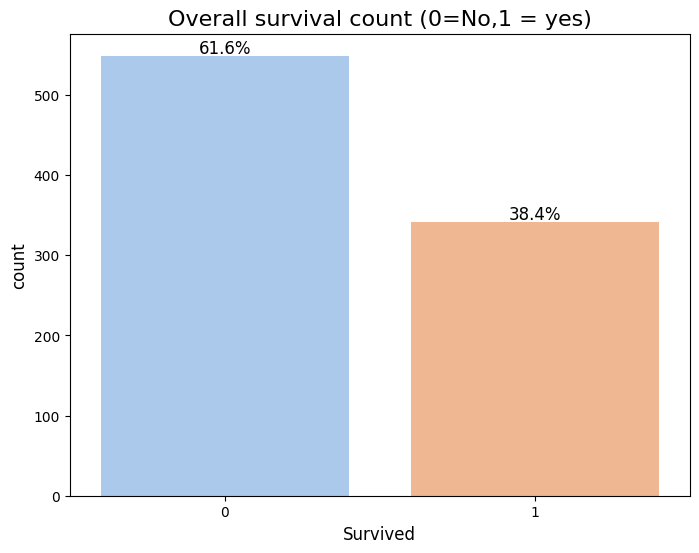

In [10]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x="Survived",data=df,palette="pastel")
plt.title("Overall survival count (0=No,1 = yes)", fontsize = 16)
plt.xlabel("Survived",fontsize =12)
plt.ylabel("count",fontsize=12)

# Add percentage labels on top of the bars

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

**Question 2: How did survival rates differ by gender?**

**Insight:** We want to test the "women and children first" hypothesis by comparing survival rates between males and females.

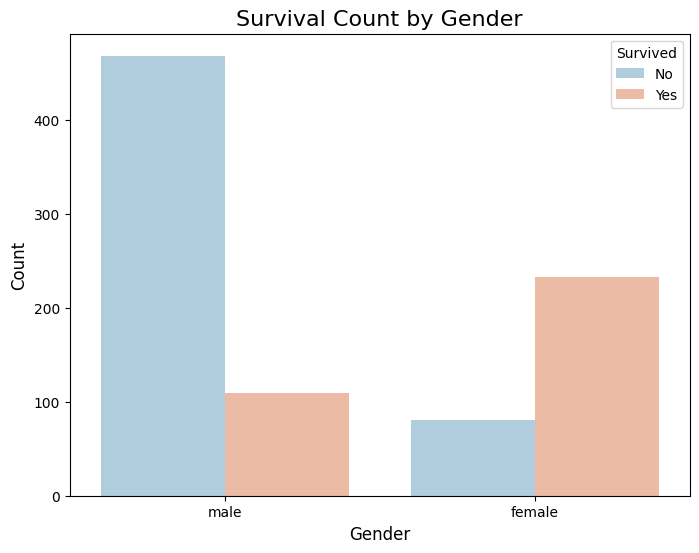

In [11]:

1
plt.figure(figsize=(8, 6))
2
sns.countplot(x='Sex', hue='Survived', data=df, palette='RdBu_r')
3
plt.title('Survival Count by Gender', fontsize=16)
4
plt.xlabel('Gender', fontsize=12)
5
plt.ylabel('Count', fontsize=12)
6
plt.legend(title='Survived', labels=['No', 'Yes'])
7
plt.show()

## **Question 3: Did a passenger's class (`Pclass`) affect their survival?**

3
**Insight:** We want to investigate if socio-economic status, represented by ticket class, had an impact on survival 

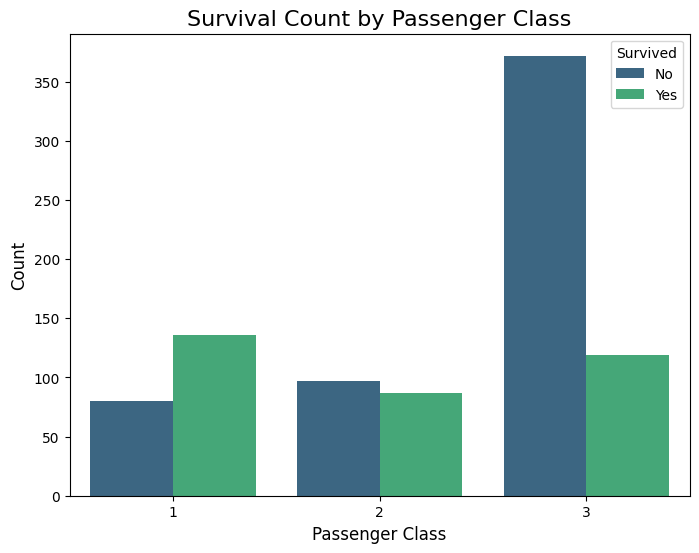

In [12]:


plt.figure(figsize=(8, 6))

sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')

plt.title('Survival Count by Passenger Class', fontsize=16)

plt.xlabel('Passenger Class', fontsize=12)

plt.ylabel('Count', fontsize=12)

plt.legend(title='Survived', labels=['No', 'Yes'])

plt.show()




1
### **Question 4: How did age influence survival?**
2
​
3
**Insight:** We want to see if there's a difference in the age distribution between those who survived and those who didn't. Were children prioritized?





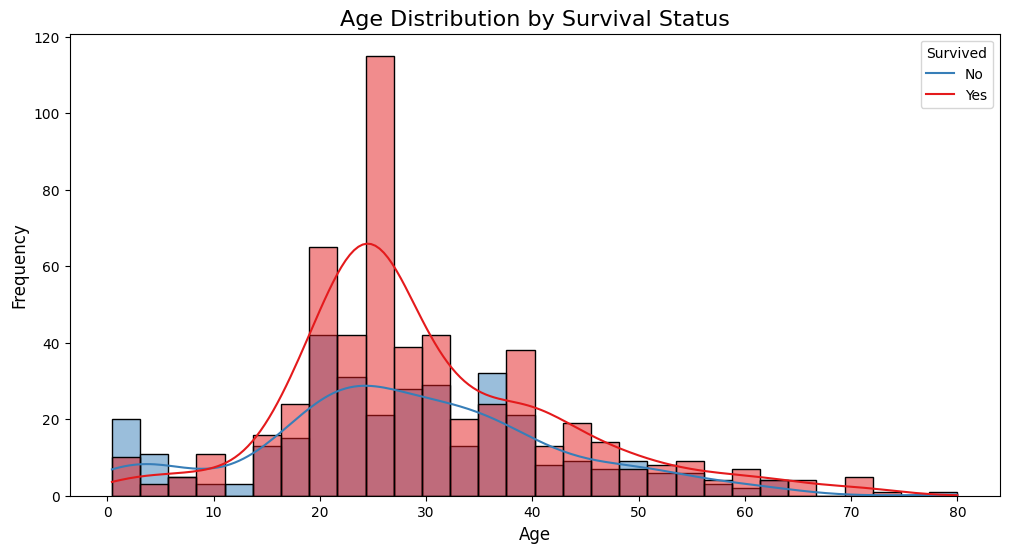

In [13]:

1
plt.figure(figsize=(12, 6))
2
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette='Set1')
3
plt.title('Age Distribution by Survival Status', fontsize=16)
4
plt.xlabel('Age', fontsize=12)
5
plt.ylabel('Frequency', fontsize=12)
6
plt.legend(title='Survived', labels=['No', 'Yes'])
7

plt.show()






### **Question 5: Did family size impact survival?**

**Insight:** We want to analyze if traveling alone or with family affected a passenger's chances of survival.
4
​
5
### **Question 6: What is the relationship between Class, Gender, and Survival?**
6
​
7
**Insight:** This is a crucial question. We want to see how the most powerful factors (`Pclass` and `Sex`) interact. A `catplot` is perfect for this, as it creates subplots for easy comparison.


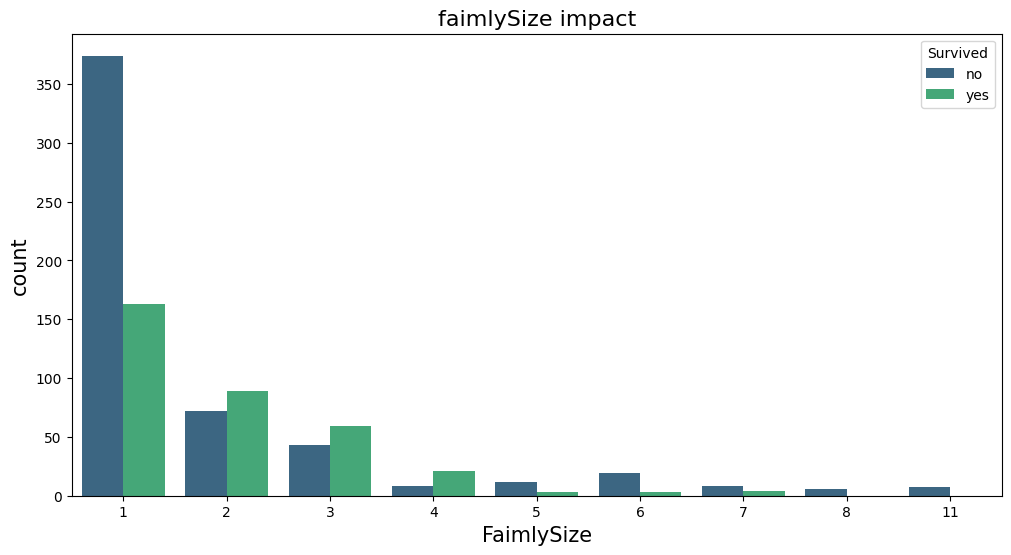

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(x= "FamilySize", hue="Survived",data=df, palette="viridis")
plt.title("faimlySize impact",fontsize = 16)
plt.xlabel("FaimlySize",fontsize =15)
plt.ylabel("count",fontsize=15)
plt.legend(title="Survived", labels=["no","yes"])

plt.show()

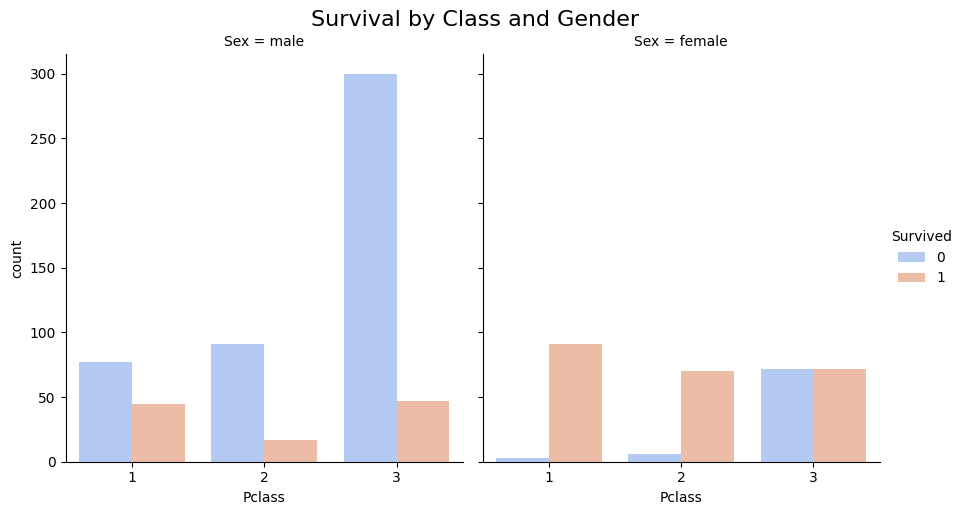

In [15]:
sns.catplot(x='Pclass', col='Sex', hue='Survived', data=df, kind='count', height=5, aspect=0.9, palette='coolwarm')
10
plt.suptitle('Survival by Class and Gender', y=1.02, fontsize=16)
11
plt.show()

Question 7-- Check corrleation of all numerical columns 

Quesrion-8 Pairplot graph based on four colkumns[['Age', 'Fare', 'Pclass', 'Survived']



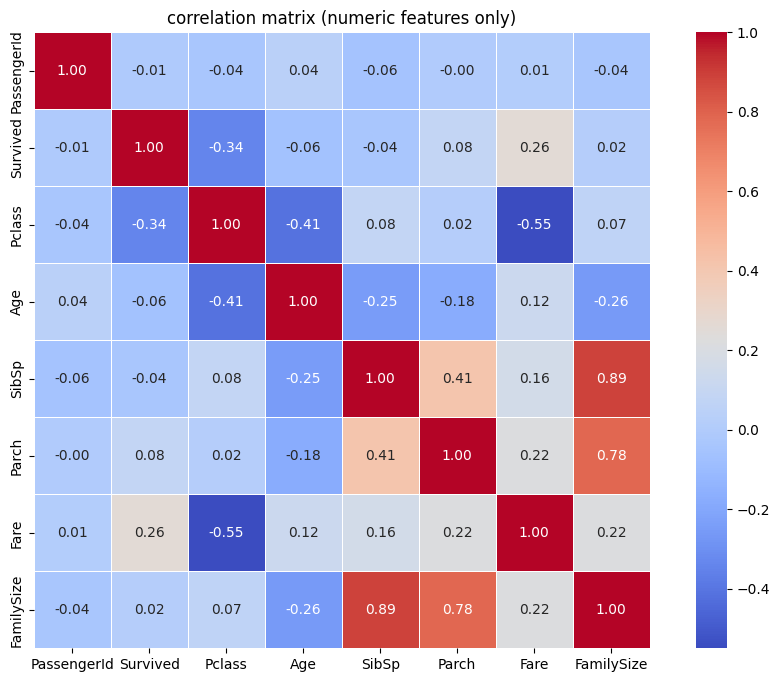

In [16]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr_matrix= numeric_df.corr()

# ---plot with seaborn---
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,       
    annot= True,          #show number inside the heatmap 
    cmap= "coolwarm",      # color map
    fmt=".2f" ,             # number format
    linewidths= 0.5,        #line between cells
    square= True,           # square cells
    cbar=True               # color bar
)

plt.title("correlation matrix (numeric features only)")
plt.show()

In [17]:
df.to_csv("df.csv",index=True)

In [18]:
# print(df.head(5))
# print(df["Age"].var())
# print(df.describe())
# df["Age"].std()
# sns.histplot(x="Age",data=df)
# plt.show()

In [19]:
# df.head(5)
# mn = df["Age"].mean()
# print(mn)
# md = df["Age"].median()
# df.isnull().sum()
# sns.histplot(x ="Age",data=df,bins=[i for i in range(0,81,10)])
# plt.plot([mn for i in range(0,400)] ,[i for i in range(0,400)],c= 'red')
# plt.plot([md for i in range(0,400)] ,[i for i in range(0,400)],c= 'blue')
# plt.show
# md = df["Age"].median()
# np.median(df["Age"])

In [20]:
# sec_a = np.array([75,65,73,68,72,76])
# sec_b = np.array([90,47,43,96,93,51])
# no = np.array([1,2,3,4,5,6])


In [21]:
# mean = np.mean(sec_a)
# mean

In [22]:
# plt.figure(figsize=(10,3))
# plt.scatter(sec_a,no,label = "SEC A")
# plt.scatter(sec_b,no,c="red",label = "SEC B")
# plt.plot([mean for i in range(1,7)],no,c= "blue",label= "mean")
# plt.legend()
# plt.show()